# Plot a ground track from an Earth-fixed ephemeris

This notebook drives the new `EphemerisFile` parser end-to-end:

1. Load a small mission script that writes an `EphemerisFile` in an Earth-fixed frame.
2. Run the mission and grab `result.ephemerides["EF"]` as a DataFrame.
3. Project the body-fixed state vector onto (lon, lat) and plot the ground track on an equirectangular world map.

We drive a minimal LEO mission script that ships next to this notebook (`ground_track_leo.script` — Keplerian initial state at ISS-like inclination, point-mass Earth, 24 hours of propagation, single `EphemerisFile` written in `CoordinateSystem = EarthFixed`). Because GMAT writes the ephemeris in the rotating Earth frame, the notebook never has to do a frame transform — only a spherical-coordinates projection.

**Prerequisites.** A local GMAT install (R2026a is the primary development target) and `pip install gmat-run[examples]` for the matplotlib dependency.

## Set up the run

Resolve the GMAT install once and confirm the script and the world-map background image are where we expect them. Both ship next to this notebook so the paths are machine-independent.

In [1]:
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

from gmat_run import Mission, locate_gmat

install = locate_gmat()
script_path = Path("ground_track_leo.script").resolve()
map_path = Path("world_map.jpg").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name} (exists: {script_path.exists()})")
print(f"World map:    {map_path.name} (exists: {map_path.exists()})")

GMAT version: R2026a
Script:       ground_track_leo.script (exists: True)
World map:    world_map.jpg (exists: True)


## Load and run

`Mission.load` parses the `.script` into the live GMAT object graph and `mission.run()` executes the mission sequence headlessly. The script declares one `EphemerisFile` named `EF`, so the parsed DataFrame is at `result.ephemerides["EF"]`.

The CCSDS-OEM parser surfaces the file's reference frame on `df.attrs["coordinate_system"]`. GMAT labels its `EarthFixed` axes as `TDR` (true-of-date rotating) when it writes the OEM header — that's the rotating Earth frame, which is what we need to plot a ground track.

In [2]:
mission = Mission.load(script_path)
result = mission.run()
ephem = result.ephemerides["EF"]

print(f"Records:           {len(ephem)}")
print(f"Coordinate system: {ephem.attrs.get('coordinate_system')!r}")
print(f"Time scale:        {ephem.attrs.get('time_scale')!r}")
ephem.head()

Records:           1441
Coordinate system: 'TDR'
Time scale:        'UTC'


,Epoch,X,Y,Z,VX,VY,VZ
0,2026-01-01 12:00:00,-1838.647117,-3808.296771,5308.858781,6.620902,-3.203928,-0.005275
1,2026-01-01 12:01:00,-1438.327446,-3993.459869,5296.366432,6.718367,-2.965973,-0.410978
2,2026-01-01 12:02:00,-1033.012407,-4163.957658,5259.578904,6.787369,-2.715229,-0.814803
3,2026-01-01 12:03:00,-624.416514,-4319.049243,5198.664352,6.827705,-2.452583,-1.214908
4,2026-01-01 12:04:00,-214.262982,-4458.048285,5113.900953,6.839287,-2.178970,-1.609465


## Project body-fixed state to (lon, lat)

With (X, Y, Z) already in Earth-fixed axes, geocentric longitude and latitude are two `arctan2` calls:

$$
\lambda = \mathrm{atan2}(Y,\;X), \qquad \varphi = \mathrm{atan2}\!\bigl(Z,\;\sqrt{X^2 + Y^2}\bigr).
$$

Geocentric latitude differs from WGS-84 geodetic by at most ~0.2° at LEO altitudes — invisible at this plot resolution, and a fair trade for keeping the notebook free of an iterative geodetic conversion.

Each pass crosses the antimeridian (±180°) once. Without intervention, matplotlib draws a horizontal line straight across the map at every wrap. We split the polyline by inserting `NaN` wherever consecutive longitudes jump by more than 180°.

In [3]:
xy = np.hypot(ephem["X"], ephem["Y"])
lon_deg = np.degrees(np.arctan2(ephem["Y"], ephem["X"])).to_numpy()
lat_deg = np.degrees(np.arctan2(ephem["Z"], xy)).to_numpy()

wrap_idx = np.where(np.abs(np.diff(lon_deg)) > 180)[0]
lon_plot = np.insert(lon_deg, wrap_idx + 1, np.nan)
lat_plot = np.insert(lat_deg, wrap_idx + 1, np.nan)

print(f"Antimeridian crossings: {len(wrap_idx)}")

Antimeridian crossings: 14


## Plot the ground track

Draw the equirectangular world map as the background, then overlay the ground track. The track stays inside ±51.6° latitude (the spacecraft's inclination) and drifts westward as the Earth rotates underneath the orbit.

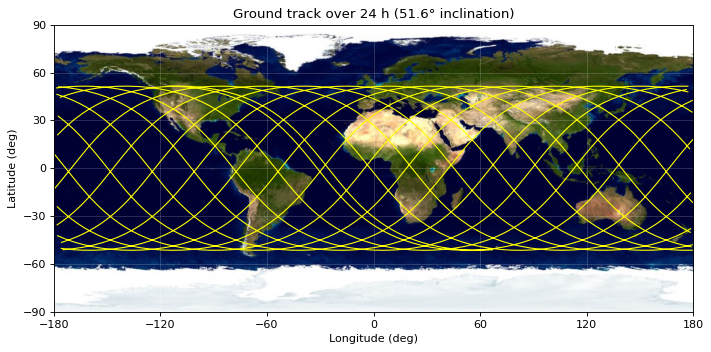

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=80)
ax.imshow(
    mpimg.imread(map_path),
    extent=(-180, 180, -90, 90),
    aspect="auto",
    interpolation="bilinear",
)
ax.plot(lon_plot, lat_plot, color="yellow", linewidth=1.0)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks(range(-180, 181, 60))
ax.set_yticks(range(-90, 91, 30))
ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Latitude (deg)")
ax.set_title("Ground track over 24 h (51.6° inclination)")
ax.grid(True, alpha=0.3, color="white", linewidth=0.5)
fig.tight_layout()
plt.show()

## Where to next

- **Other ephemeris formats.** `result.ephemerides` also handles GMAT's STK-TimePosVel writer (`FileFormat = STK-TimePosVel`); the parser sniffs the file and routes accordingly, so the call site is unchanged.
- **Override the orbit from Python.** Sweep `Sat.INC`, `Sat.RAAN`, or `Sat.SMA` between runs the same way [notebook 2](02_parameter_sweep.ipynb) sweeps `Sat.SMA` — each run produces its own ground track.
- **Persist the artefacts.** `result.persist("./run_outputs")` after `run()` copies the EphemerisFile (and any ReportFile / ContactLocator output) into a permanent location before the temp workspace is cleaned up.

*Background image: NASA "Blue Marble: Land Surface, Ocean Color and Sea Ice" composite, public domain, via Wikimedia Commons.*